# Vectors and Their Properties

*Course notes for **Math for Machine Learning**, C1 · W3 · L1 · V02 — "Vectors and Their Properties" (DeepLearning.AI).*

A vector is one of the fundamental objects of linear algebra. This lecture builds intuition for what a vector *is* geometrically, and then defines its two essential properties:

- **Magnitude** (size) — measured by a *norm* (the $L_1$ "taxicab" norm and the $L_2$ "helicopter" norm).
- **Direction** — recovered from the coordinates via trigonometry.

We finish with the common **notations** for vectors and the general definition of the norms in $n$ dimensions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. What is a vector?

A **vector** is described by a list of **coordinates**. Geometrically it is an *arrow from the origin* to the point with those coordinates.

- In the plane ($\mathbb{R}^2$), the vector $(4, 3)$ is the arrow pointing at horizontal coordinate $4$ and vertical coordinate $3$.
- In 3D space ($\mathbb{R}^3$), the vector $(4, 3, 1)$ points at coordinates $4, 3, 1$ with respect to the $x$, $y$, $z$ axes.

A vector carries **two important pieces of information**: its **magnitude** (size) and its **direction**.

In [2]:
v = np.array([4, 3])
print('vector v =', v)
print('lives in R^%d (dimension = number of coordinates)' % v.shape[0])

w = np.array([4, 3, 1])
print('vector w =', w, ' lives in R^%d' % w.shape[0])

vector v = [4 3]
lives in R^2 (dimension = number of coordinates)
vector w = [4 3 1]  lives in R^3


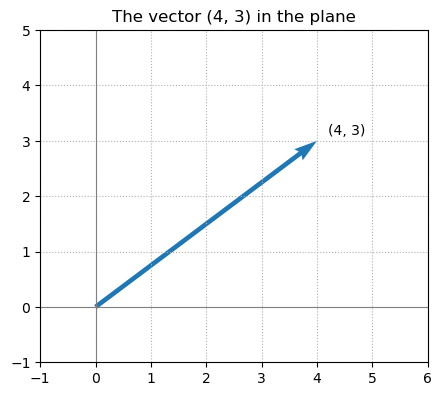

In [3]:
# Draw the vector (4, 3) as an arrow from the origin
fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='C0', width=0.012)
ax.annotate('(4, 3)', (v[0], v[1]), textcoords='offset points', xytext=(8, 4))
ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_aspect('equal'); ax.grid(True, ls=':')
ax.set_title('The vector (4, 3) in the plane')
plt.show()

## 2. Magnitude — two ways to measure size

The size of a vector can be defined in several ways, all of which mimic distances used in real life. Imagine you live in a city of square blocks and want to go from **home (origin)** to the **store** at $(4, 3)$.

### 2.1 The taxicab distance → the $L_1$ norm

A car can only drive **along the streets** (horizontal / vertical moves). To reach a store $4$ blocks across and $3$ blocks up you travel $4 + 3 = 7$ blocks — and *no matter which route* you take, it is always $7$ blocks.

This is the **$L_1$ norm** (taxicab distance from the origin):

$$ \|(a, b)\|_1 = |a| + |b| $$

We use **absolute values** because coordinates may be negative, but a walked distance is always positive.

### 2.2 The helicopter distance → the $L_2$ norm

Forget the car — take a **helicopter** that flies in a straight line, ignoring streets and corners. By the **Pythagorean theorem** the straight-line distance is

$$ \|(a, b)\|_2 = \sqrt{a^2 + b^2}, \qquad \sqrt{4^2 + 3^2} = \sqrt{25} = 5. $$

The $L_2$ norm is the **length of the arrow** itself. It is the **default** norm: whenever a norm is written without a subscript, $\|v\|$ means $\|v\|_2$, because it is the most natural measure of size.

In [4]:
a, b = v  # (4, 3)

# L1 norm (taxicab): sum of absolute values
l1 = np.abs(a) + np.abs(b)
print('L1 (taxicab) =', l1, ' -> also np.linalg.norm(v, 1) =', np.linalg.norm(v, 1))

# L2 norm (helicopter): Pythagoras
l2 = np.sqrt(a**2 + b**2)
print('L2 (helicopter) =', l2, ' -> also np.linalg.norm(v) =', np.linalg.norm(v))

L1 (taxicab) = 7  -> also np.linalg.norm(v, 1) = 7.0
L2 (helicopter) = 5.0  -> also np.linalg.norm(v) = 5.0


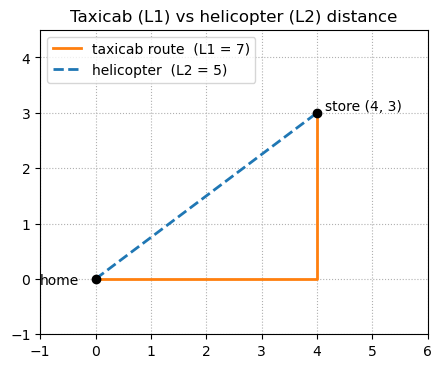

In [5]:
# Visual: taxicab path (steps) vs helicopter path (straight line)
fig, ax = plt.subplots(figsize=(5, 5))

# one taxicab route: along x then along y
ax.plot([0, 4, 4], [0, 0, 3], color='C1', lw=2, label='taxicab route  (L1 = 7)')
# helicopter straight line
ax.plot([0, 4], [0, 3], color='C0', lw=2, ls='--', label='helicopter  (L2 = 5)')
ax.scatter([0, 4], [0, 3], color='k', zorder=5)
ax.annotate('home', (0, 0), textcoords='offset points', xytext=(-40, -4))
ax.annotate('store (4, 3)', (4, 3), textcoords='offset points', xytext=(6, 2))

ax.set_xlim(-1, 6); ax.set_ylim(-1, 4.5)
ax.set_aspect('equal'); ax.grid(True, ls=':')
ax.legend(loc='upper left')
ax.set_title('Taxicab (L1) vs helicopter (L2) distance')
plt.show()

## 3. Direction

The **direction** of a vector can also be deduced from its coordinates. For $(4, 3)$, if $\theta$ is the angle with the horizontal axis, then

$$ \tan\theta = \frac{3}{4} \quad\Longrightarrow\quad \theta = \arctan\!\left(\tfrac{3}{4}\right) \approx 0.64\ \text{rad} \approx 36.87^\circ. $$

In [6]:
theta = np.arctan2(b, a)   # arctan2 handles all quadrants correctly
print('theta = %.4f rad' % theta)
print('theta = %.2f degrees' % np.degrees(theta))

theta = 0.6435 rad
theta = 36.87 degrees


## 4. Same direction, different magnitude

Two vectors can share the **same direction** while having **different norms**. The vector $(2, 1.5)$ points in exactly the same direction as $(4, 3)$ — it is just *scaled down* — so it has the same angle $\theta$ but a smaller magnitude.

In general, multiplying a vector by a positive scalar $c$ keeps its direction and scales its norm by $c$: $\;\|c\,v\|_2 = c\,\|v\|_2$.

In [7]:
v1 = np.array([4, 3])
v2 = np.array([2, 1.5])   # = 0.5 * v1

for name, vec in [('v1', v1), ('v2', v2)]:
    ang = np.degrees(np.arctan2(vec[1], vec[0]))
    print(f'{name} = {vec}   L2 = {np.linalg.norm(vec):.3f}   angle = {ang:.2f} deg')

v1 = [4 3]   L2 = 5.000   angle = 36.87 deg
v2 = [2.  1.5]   L2 = 2.500   angle = 36.87 deg


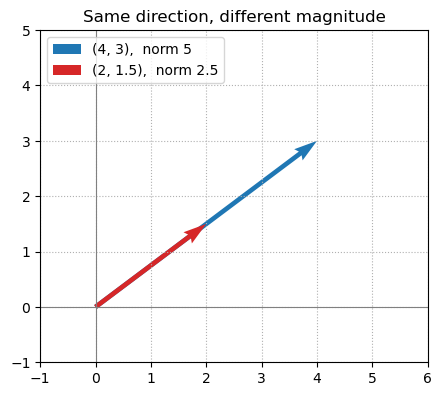

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='C0', width=0.012, label='(4, 3),  norm 5')
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='C3', width=0.012, label='(2, 1.5),  norm 2.5')
ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.axhline(0, color='gray', lw=0.8); ax.axvline(0, color='gray', lw=0.8)
ax.set_aspect('equal'); ax.grid(True, ls=':')
ax.legend(loc='upper left')
ax.set_title('Same direction, different magnitude')
plt.show()

## 5. Vector notation

There are many notations for the same vector $x$; you will meet all of them in the wild.

| Idea | Notation |
|---|---|
| **Row vector** (horizontal) | $x = (x_1, x_2, \dots, x_n)$ |
| **Column vector** (vertical) | $x = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{pmatrix}$ |
| **Components** are numbered with subscripts | the 2nd component of $x$ is $x_2$ |
| Arrow or **bold** to flag "this is a vector" | $\vec{x}$ or $\mathbf{x}$ |
| **Square brackets** instead of parentheses | $[\,x_1, x_2\,]$ |

Square brackets are a helpful reminder that a vector is really a *small, skinny matrix* (part of a matrix) — but there is **no conceptual difference** between $(\cdot)$ and $[\cdot]$. In this course we simply write plain $x$, and use both parentheses and brackets depending on context.

In [9]:
x = np.array([4, 3, 1])

print('row vector  x =', x)
print('column vector x =')
print(x.reshape(-1, 1))
print()
print('component x_2 (1-indexed like the math) =', x[1])   # Python is 0-indexed

row vector  x = [4 3 1]
column vector x =
[[4]
 [3]
 [1]]

component x_2 (1-indexed like the math) = 3


## 6. Generalizing the norms to $n$ dimensions

For a vector $x = (x_1, x_2, \dots, x_n)$ with $n$ components, the two norms generalize naturally:

$$ \|x\|_1 = \sum_{i=1}^{n} |x_i| \qquad\text{($L_1$: sum of absolute values)} $$

$$ \|x\|_2 = \sqrt{\sum_{i=1}^{n} x_i^{\,2}} \qquad\text{($L_2$: square root of the sum of squares)} $$

In [10]:
def l1_norm(x):
    return np.sum(np.abs(x))

def l2_norm(x):
    return np.sqrt(np.sum(x**2))

x = np.array([4.0, 3.0, 1.0, -2.0])
print('x       =', x)
print('L1 norm =', l1_norm(x), ' (check:', np.linalg.norm(x, 1), ')')
print('L2 norm =', l2_norm(x), ' (check:', np.linalg.norm(x, 2), ')')

x       = [ 4.  3.  1. -2.]
L1 norm = 10.0  (check: 10.0 )
L2 norm = 5.477225575051661  (check: 5.477225575051661 )


## Summary

- A **vector** is a list of coordinates, pictured as an arrow from the origin; the number of coordinates is its **dimension**.
- Its two properties are **magnitude** and **direction**.
- **Magnitude** is measured by a *norm*:
  - $L_1$ (taxicab) $= \sum_i |x_i|$,
  - $L_2$ (helicopter / Euclidean) $= \sqrt{\sum_i x_i^2}$ — the arrow's length, and the **default** norm.
- **Direction** comes from the coordinates via $\theta = \arctan(y/x)$.
- Scaling a vector by a positive constant keeps its **direction** and scales its **magnitude**.
- Notation varies (row/column, subscripts, arrows/bold, parentheses/brackets) but the underlying object is the same.